In [ ]:
most_frequent_ingredients = ['Salt', 'Sugar', 'Onion', 'Milk', 'Garlic clove']

# Restaurant data with the 25 most frequent ingredients
restaurant_data_df = load_file('../data/kaggle/Restaurant_frequent_ings.csv') 
restaurant_data_df['Ingredient'] = restaurant_data_df['Ingredient'].str.capitalize()

# Filter restaurant data by most frequent ingredients
restaurant_freq_ings_df = (restaurant_data_df[restaurant_data_df['Ingredient'].isin(most_frequent_ingredients)].copy()) # type: ignore
#display(restaurant_freq_ings_df)
#restaurant_freq_ings_df = restaurant_data_df.copy()

# Convert DateTime column to datetime type
restaurant_freq_ings_df['DateTime'] = pd.to_datetime(restaurant_freq_ings_df['DateTime'])

# Resolve DayType problem 
restaurant_freq_ings_df['DayOfWeek'] = restaurant_freq_ings_df['DateTime'].dt.day_name()
restaurant_freq_ings_df['DayType'] = restaurant_freq_ings_df['DayOfWeek'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')

# Extract date from DateTime 
restaurant_freq_ings_df['Date'] = restaurant_freq_ings_df['DateTime'].dt.date 

# Group by Day, Ingredient, and DayType
consumption_df = restaurant_freq_ings_df.groupby(['Date', 'Ingredient', 'DayType'])['Total Quantity'].sum().reset_index() 
#display(consumption_df)

# Pivot the DataFrame to get quantities per ingredient
pivot_df = consumption_df.pivot_table(index='Date', columns=['Ingredient'], values='Total Quantity', fill_value=0)
pivot_df.columns.name = None

# Create a DataFrame for DayType to merge it later
daytype_df = consumption_df[['Date', 'DayType']].drop_duplicates().set_index('Date')

# Merge pivot_df and daytype_df
daily_consumption_df = pivot_df.merge(daytype_df, left_index=True, right_index=True)
display(daily_consumption_df)

In [ ]:
# Generate futute dates
last_date = time_sequences_df.index[-1]
 
# Generate the next 9 dates
future_dates = pd.date_range(start=last_date + pd.DateOffset(1), periods=9)
 
# Concatenate the original index with the future dates
forecast_dates = time_sequences_df.index.append(future_dates)

# Convert to DatetimeIndex and normalize the dates
forecast_dates = pd.DatetimeIndex(forecast_dates).normalize()

# Select only the forecasted range
forecast_dates = forecast_dates[-(num_forecast_steps*2):]

In [23]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))
from src.utils.utils import load_file

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

,Date,DayType,Quantity
0,2019-01-01,Weekday,153.557043
1,2019-01-02,Weekend,101.122931
2,2019-01-03,Weekday,119.849399
3,2019-01-04,Weekday,97.377637
4,2019-01-05,Weekend,202.245861
...,...,...,...
176,2019-06-26,Weekend,116.104106
177,2019-06-27,Weekday,205.991155
178,2019-06-28,Weekday,179.774099
179,2019-06-29,Weekend,159.174983


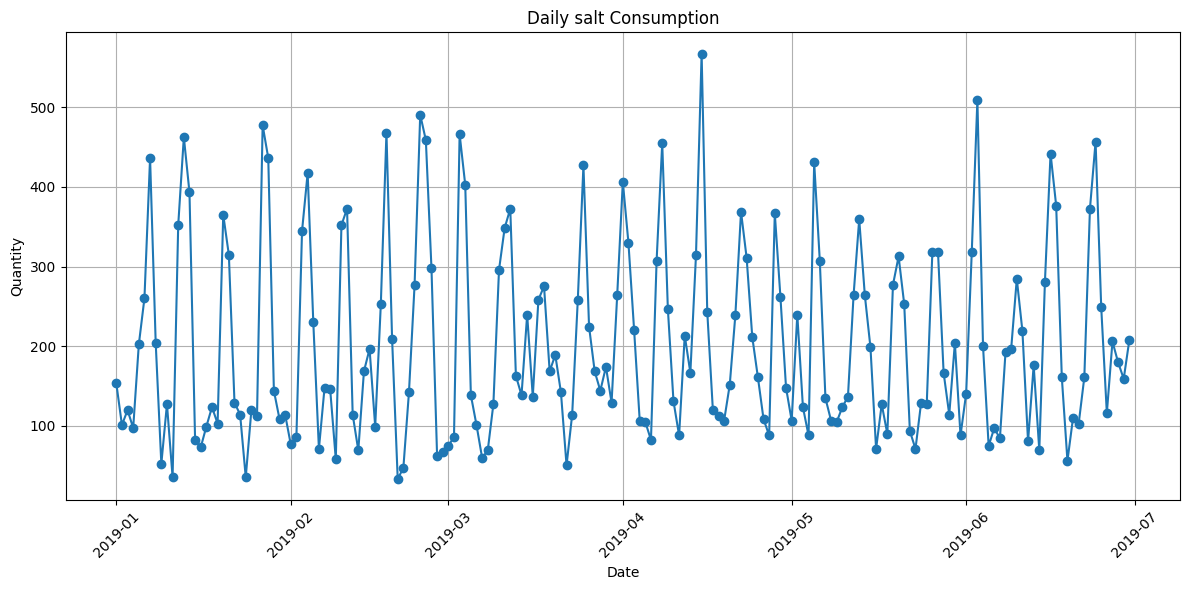

In [24]:
# Restaurant data with the 25 most frequent ingredients
restaurant_data_df = load_file('../../data/kaggle/Restaurant_frequent_ings.csv') 
#display(restaurant_data_df)

# Filter restaurant data by salt
restaurant_salt_data_df = restaurant_data_df[restaurant_data_df['Ingredient'] == 'salt'].copy()
#display(restaurant_salt_data_df)

# Obtain daily salt consumption
restaurant_salt_data_df['DateTime'] = pd.to_datetime(restaurant_salt_data_df['DateTime']) # Convert DateTime column to datetime type
restaurant_salt_data_df['Date'] = restaurant_salt_data_df['DateTime'].dt.date # Extract date from DateTime
daily_salt_consumption = restaurant_salt_data_df.groupby(['Date', 'DayType'])['Total Quantity'].sum().reset_index() # group by Day
daily_salt_consumption = daily_salt_consumption.rename(columns={'Total Quantity': 'Quantity'}) # Rename 'Total Quantity' to 'Quantity'
display(daily_salt_consumption)

# Plot daily salt consumption 
plt.figure(figsize=(12, 6))
plt.plot(daily_salt_consumption['Date'], daily_salt_consumption['Quantity'], marker='o', linestyle='-')
plt.title('Daily salt Consumption')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Assuming df is your DataFrame
daily_salt_consumption['DayType'] = LabelEncoder().fit_transform(daily_salt_consumption['DayType'])

# # Normalize the quantity
scaler = StandardScaler()
daily_salt_consumption['Quantity'] = scaler.fit_transform(daily_salt_consumption[['Quantity']])

In [26]:
daily_salt_consumption

,Date,DayType,Quantity
0,2019-01-01,0,-0.401511
1,2019-01-02,1,-0.829631
2,2019-01-03,0,-0.676731
3,2019-01-04,0,-0.860211
4,2019-01-05,1,-0.003970
...,...,...,...
176,2019-06-26,1,-0.707311
177,2019-06-27,0,0.026610
178,2019-06-28,0,-0.187451
179,2019-06-29,1,-0.355641


In [27]:
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length, 0]  # Assume 'Quantity' is the target variable
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys).reshape(-1, 1)

# Assuming df is your DataFrame and it is sorted by time
data = daily_salt_consumption[['Quantity', 'DayType']].values
seq_length = 2
X, y = create_sequences(data, seq_length)
print(f"Shape X numpy: {X.shape}, Dimensions: {X.ndim}")
print(f"Shape Y numpy: {y.shape}, Dimensions: {y.ndim}")

Shape X numpy: (179, 2, 2), Dimensions: 3
Shape Y numpy: (179, 1), Dimensions: 2


In [28]:
X

array([[[-0.4015108 ,  0.        ],
        [-0.8296313 ,  1.        ]],

       [[-0.8296313 ,  1.        ],
        [-0.67673112,  0.        ]],

       [[-0.67673112,  0.        ],
        [-0.86021134,  0.        ]],

       [[-0.86021134,  0.        ],
        [-0.00397034,  1.        ]],

       [[-0.00397034,  1.        ],
        [ 0.47002022,  1.        ]],

       [[ 0.47002022,  1.        ],
        [ 1.9072819 ,  0.        ]],

       [[ 1.9072819 ,  0.        ],
        [ 0.01131968,  0.        ]],

       [[ 0.01131968,  0.        ],
        [-1.22717177,  1.        ]],

       [[-1.22717177,  1.        ],
        [-0.61557105,  0.        ]],

       [[-0.61557105,  0.        ],
        [-1.36478193,  0.        ]],

       [[-1.36478193,  0.        ],
        [ 1.21923109,  1.        ]],

       [[ 1.21923109,  1.        ],
        [ 2.12134215,  1.        ]],

       [[ 2.12134215,  1.        ],
        [ 1.55561149,  0.        ]],

       [[ 1.55561149,  0.        ],
  

In [29]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        #display(self.X)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Split the data into training and testing
train_size = int(len(X) * 0.95)
test_size = len(X) - train_size

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [30]:
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Iterate over the train_dataloader
# for _, batch in enumerate(train_loader):
#     x_batch, y_batch = batch[0].to(device), batch[1].to(device)
#     print(x_batch.shape, y_batch.shape)
#     print(batch)
#     break

In [31]:
import torch.nn as nn

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMRegressor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

input_size = 2  # Quantity and Shift
hidden_size = 50
num_layers = 2
output_size = 1

model = LSTMRegressor(input_size, hidden_size, num_layers, output_size)

In [32]:
print(model)

LSTMRegressor(
  (lstm): LSTM(2, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [33]:
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    
    val_loss /= len(test_loader)
    val_losses.append(val_loss)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss}, Val Loss: {val_loss}')

Epoch 1/20, Train Loss: 1.0020459393660228, Val Loss: 0.778532087802887
Epoch 2/20, Train Loss: 0.9616736471652985, Val Loss: 0.772074818611145
Epoch 3/20, Train Loss: 1.0364593466122944, Val Loss: 0.7634546756744385
Epoch 4/20, Train Loss: 0.9832586546738943, Val Loss: 0.7600920796394348
Epoch 5/20, Train Loss: 0.939948707818985, Val Loss: 0.7531331777572632
Epoch 6/20, Train Loss: 1.0071201920509338, Val Loss: 0.7400230765342712
Epoch 7/20, Train Loss: 0.9517517189184824, Val Loss: 0.7243622541427612
Epoch 8/20, Train Loss: 0.9226511617501577, Val Loss: 0.6912678480148315
Epoch 9/20, Train Loss: 0.8987948298454285, Val Loss: 0.6684157848358154
Epoch 10/20, Train Loss: 0.9369968275229136, Val Loss: 0.629771888256073
Epoch 11/20, Train Loss: 0.8033292293548584, Val Loss: 0.5579622387886047
Epoch 12/20, Train Loss: 0.7438361396392187, Val Loss: 0.4699209928512573
Epoch 13/20, Train Loss: 0.6723763396342596, Val Loss: 0.3832651376724243
Epoch 14/20, Train Loss: 0.6207106510798136, Val Lo

In [34]:
def get_predictions(loader):
    model.eval()
    predictions = []
    actuals = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())
    return predictions, actuals

train_predictions, train_actuals = get_predictions(train_loader)
test_predictions, test_actuals = get_predictions(test_loader)

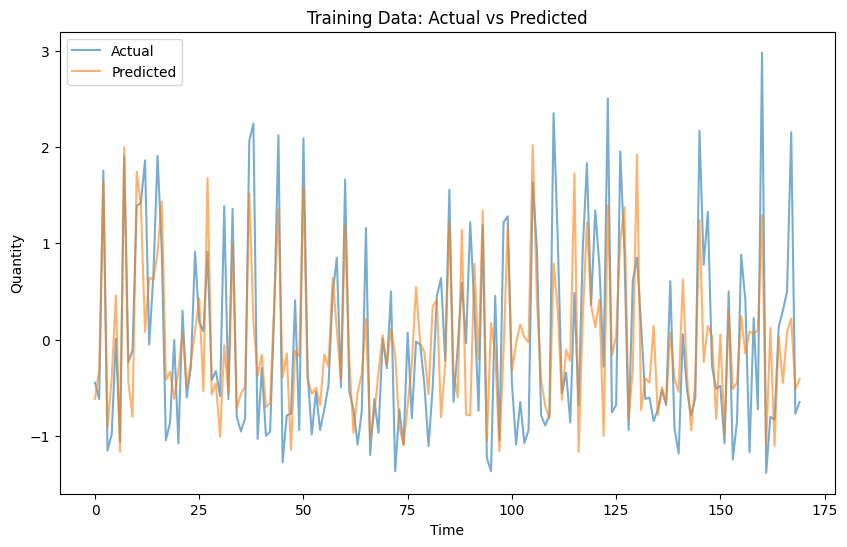

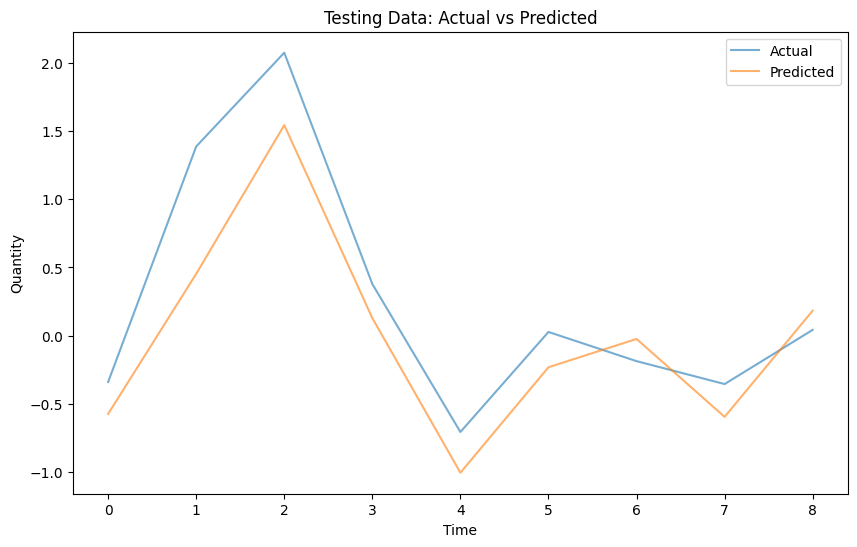

In [35]:
def plot_predictions(predictions, actuals, title):
    plt.figure(figsize=(10, 6))
    plt.plot(actuals, label='Actual', alpha=0.6)
    plt.plot(predictions, label='Predicted', alpha=0.6)
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Quantity')
    plt.legend()
    plt.show()

plot_predictions(train_predictions, train_actuals, 'Training Data: Actual vs Predicted')
plot_predictions(test_predictions, test_actuals, 'Testing Data: Actual vs Predicted')

In [36]:
# Denormalize the data
train_predictions_denorm = scaler.inverse_transform(train_predictions)
train_actuals_denorm = scaler.inverse_transform(train_actuals)
test_predictions_denorm = scaler.inverse_transform(test_predictions)
test_actuals_denorm = scaler.inverse_transform(test_actuals)

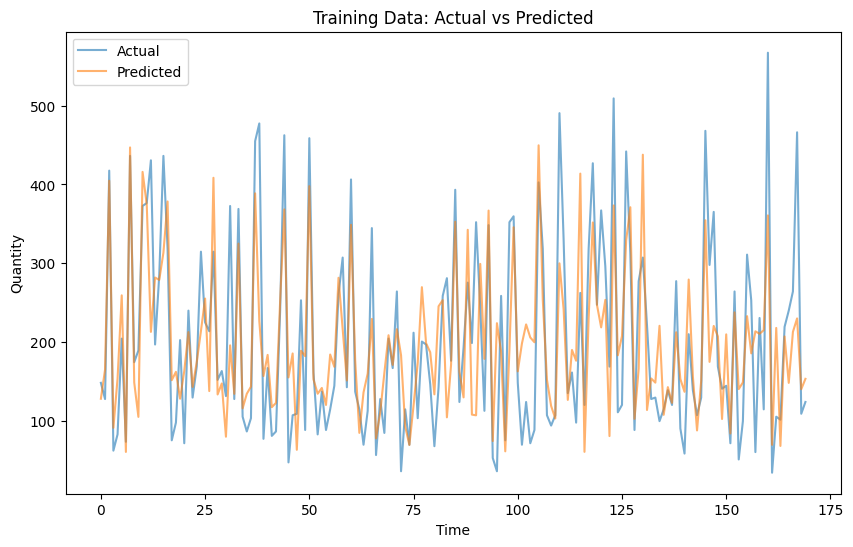

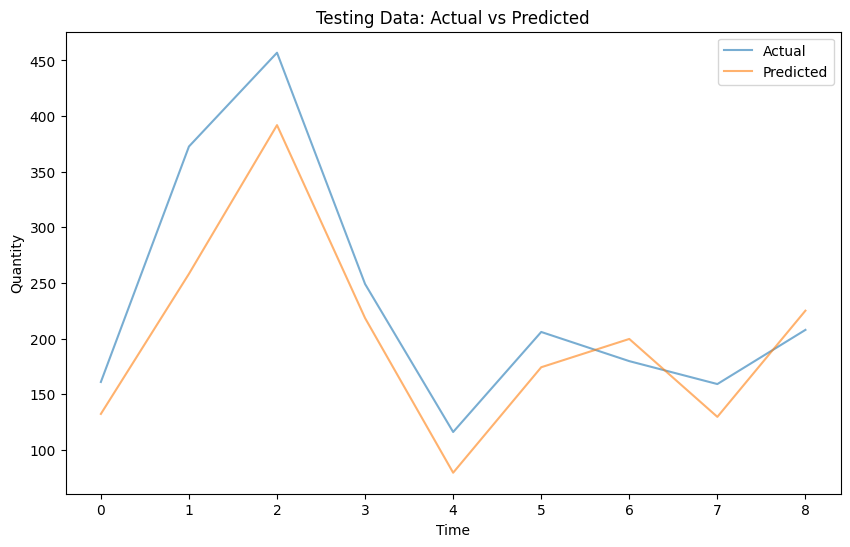

In [37]:

plot_predictions(train_predictions_denorm, train_actuals_denorm, 'Training Data: Actual vs Predicted')
plot_predictions(test_predictions_denorm, test_actuals_denorm, 'Testing Data: Actual vs Predicted')